In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from pmdarima import auto_arima
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

In [2]:
# ==========================================
# 1. LOAD AND PREPARE DATA
# ==========================================
# Load the data processed in Task 1
df = pd.read_csv('../data/processed/cleaned_prices.csv', index_col='Date', parse_dates=True)


In [3]:
# Select TSLA and ensure we have a business day frequency to avoid ARIMA warnings
tsla_data = df['TSLA'].asfreq('B').ffill()

# Split Train (2015-2024) and Test (2025-2026)
train_data = tsla_data[:'2024-12-31']
test_data = tsla_data['2025-01-01':]

print(f"Training Samples: {len(train_data)}, Test Samples: {len(test_data)}")


Training Samples: 2608, Test Samples: 271


In [4]:
# ==========================================
# 2. ARIMA MODELING (Statistical)
# ==========================================
print("\n--- Training ARIMA ---")
# auto_arima finds the best (p, d, q) automatically
model_arima = auto_arima(train_data, seasonal=False, stepwise=True, trace=True, error_action='ignore')

# Forecast for the test period
forecast_raw = model_arima.predict(n_periods=len(test_data))
# Fix: Ensure forecast index matches the test_data dates
forecast_series = pd.Series(forecast_raw.values, index=test_data.index)


--- Training ARIMA ---
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=16858.977, Time=1.17 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16873.591, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16875.541, Time=0.10 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16875.541, Time=0.11 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16873.127, Time=0.05 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=16878.233, Time=0.40 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=16878.294, Time=0.63 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=16857.881, Time=1.02 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=16878.243, Time=0.58 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=16859.734, Time=1.75 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=16862.638, Time=2.23 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=16857.948, Time=1.79 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=16874.277, Time=0.65 sec
 ARIMA(4,1,3)(0,0,0)[0] intercept   : AIC=16858.879, Time=2.04

In [5]:
# Evaluate ARIMA
rmse_arima = np.sqrt(mean_squared_error(test_data, forecast_series))
mae_arima = mean_absolute_error(test_data, forecast_series)
mape_arima = mean_absolute_percentage_error(test_data, forecast_series)

print(f"ARIMA Results -> RMSE: {rmse_arima:.2f}, MAE: {mae_arima:.2f}")


ARIMA Results -> RMSE: 83.22, MAE: 69.43


In [6]:
# ==========================================
# 3. LSTM MODELING (Deep Learning)
# ==========================================
print("\n--- Training LSTM ---")
# Scale Data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(tsla_data.values.reshape(-1, 1))

def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length, 0])
        y.append(data[i+seq_length, 0])
    return np.array(X), np.array(y)

SEQ_LENGTH = 60
train_len = len(train_data)

# Create sequences for training
train_scaled = scaled_data[:train_len]
X_train, y_train = create_sequences(train_scaled, SEQ_LENGTH)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))


--- Training LSTM ---


In [7]:
# Create sequences for testing (needs last 60 days of train)
test_inputs = scaled_data[train_len - SEQ_LENGTH:]
X_test, y_test = create_sequences(test_inputs, SEQ_LENGTH)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Build LSTM Model
model_lstm = Sequential([
    Input(shape=(X_train.shape[1], 1)),
    LSTM(50, return_sequences=True),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mean_squared_error')
model_lstm.fit(X_train, y_train, batch_size=32, epochs=10, verbose=0) 

In [8]:
# Predict
lstm_preds_scaled = model_lstm.predict(X_test)
lstm_preds = scaler.inverse_transform(lstm_preds_scaled)
lstm_series = pd.Series(lstm_preds.flatten(), index=test_data.index)

# Evaluate LSTM
rmse_lstm = np.sqrt(mean_squared_error(test_data, lstm_series))
mae_lstm = mean_absolute_error(test_data, lstm_series)
mape_lstm = mean_absolute_percentage_error(test_data, lstm_series)

print(f"LSTM Results -> RMSE: {rmse_lstm:.2f}, MAE: {mae_lstm:.2f}")


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
LSTM Results -> RMSE: 20.17, MAE: 15.84


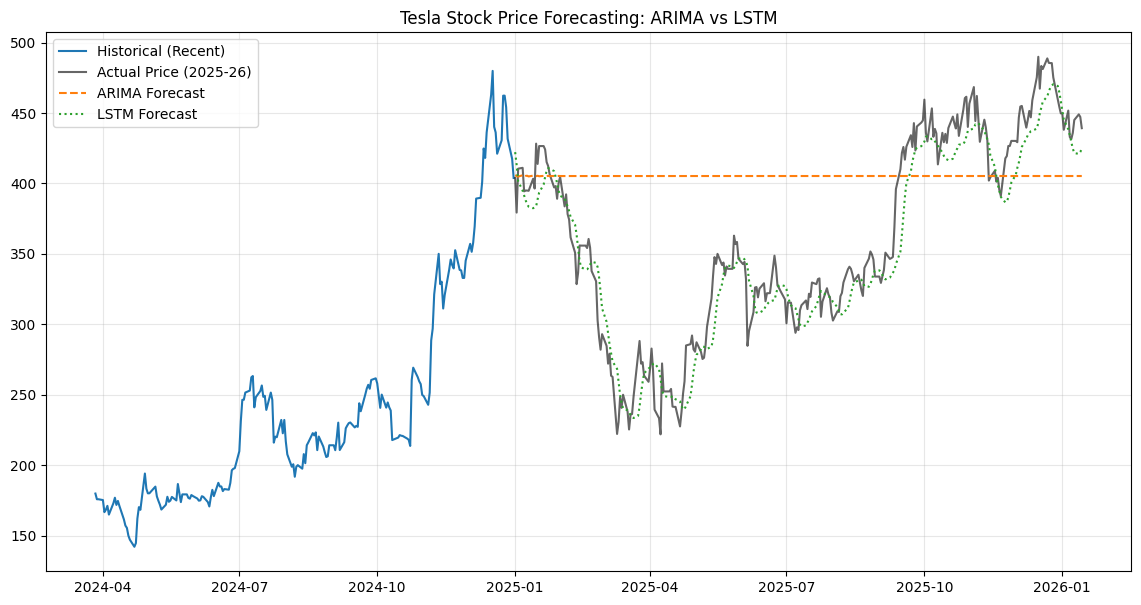


Model Comparison Table:
  Metric      ARIMA       LSTM
0   RMSE  83.223673  20.173808
1    MAE  69.433449  15.841946
2   MAPE   0.225357   0.045021


In [9]:
# ==========================================
# 4. COMPARISON AND VISUALIZATION
# ==========================================
plt.figure(figsize=(14, 7))
plt.plot(train_data.index[-200:], train_data[-200:], label='Historical (Recent)')
plt.plot(test_data.index, test_data, label='Actual Price (2025-26)', color='black', alpha=0.6)
plt.plot(forecast_series.index, forecast_series, label='ARIMA Forecast', linestyle='--')
plt.plot(lstm_series.index, lstm_series, label='LSTM Forecast', linestyle=':')
plt.title('Tesla Stock Price Forecasting: ARIMA vs LSTM')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print Comparison Table
metrics_df = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'MAPE'],
    'ARIMA': [rmse_arima, mae_arima, mape_arima],
    'LSTM': [rmse_lstm, mae_lstm, mape_lstm]
})
print("\nModel Comparison Table:")
print(metrics_df)

In [10]:
# ==========================================
# 5. TASK 3: FUTURE TREND FORECASTING
# ==========================================
print("\n--- Task 3: Future Forecast ---")
# Use the best model (typically LSTM or a re-fitted ARIMA on full data)
# Here we re-fit ARIMA on ALL data to project into the unknown future
full_model = auto_arima(tsla_data, seasonal=False, suppress_warnings=True)

# Forecast 6 months ahead (~126 trading days)
future_steps = 126 
future_forecast = full_model.predict(n_periods=future_steps)

current_price = tsla_data.iloc[-1]
final_predicted_price = future_forecast.iloc[-1]

# Calculate Expected Return for Portfolio Optimization (Task 4)
expected_return_tsla = (final_predicted_price - current_price) / current_price
annualized_return_tsla = expected_return_tsla * (252 / future_steps)

print("-" * 40)
print(f"Current Date: {tsla_data.index[-1].date()}")
print(f"Current Price: ${current_price:.2f}")
print(f"Forecasted Price (6mo): ${final_predicted_price:.2f}")
print(f"Annualized Expected Return (TSLA): {annualized_return_tsla:.4f}")
print("-" * 40)
print("SAVE THE 'Annualized Expected Return' FOR TASK 4 OPTIMIZATION.")


--- Task 3: Future Forecast ---
----------------------------------------
Current Date: 2026-01-14
Current Price: $439.20
Forecasted Price (6mo): $439.46
Annualized Expected Return (TSLA): 0.0012
----------------------------------------
SAVE THE 'Annualized Expected Return' FOR TASK 4 OPTIMIZATION.
